# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import (compute_gell_mann_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bipartite_region_upper, compute_bipartite_region_ent, compute_bipartite_region_lower)
from moments.optimization import OptimizationResult, opt_moment_preserving_ent

# Saving
from moments.saving import get_experiment_paths

data_dir, _ = get_experiment_paths(__vsc_ipynb_file__)

# Hilbert apace definition

In [2]:
dn = 3
dim = [dn, dn]
N = len(dim)

basis = compute_gell_mann_basis(dn)
local_bases = [basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

## Analytical conditions and moment space discretization

There exist analytical conditions that partially define the region, given by

- $x \in [0, \sqrt2]$, $y = 0$, $z \in [0, 2\sqrt2]$,
- $z \ge \sqrt2 x - 2$,
- $z^2 \le 8 - 3 \sqrt6 x + 2 x^2$.

The rest of the region is defined numerically.


In [3]:
data_dir = data_dir.parent / "polytope"

bloch_distance = np.load(data_dir / "xz_bloch_distance.npy")
Dx, Dz = bloch_distance.shape

x = np.linspace(0, np.sqrt(2), Dx)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

indices = np.ndindex(X.shape)
success = np.full_like(X, np.False_)
for idx, jdx in indices:
    if bloch_distance[idx, jdx] <= 1e-3:
        success[idx, jdx] = np.True_

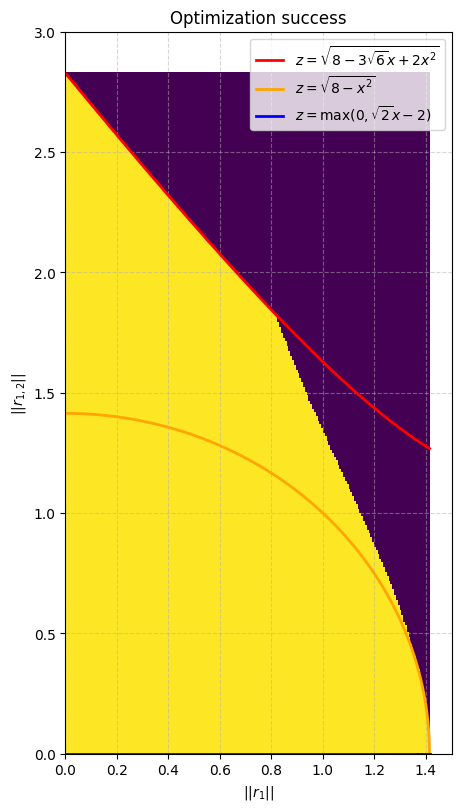

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 8), constrained_layout=True)

mesh = ax.pcolormesh(X, Z, success, shading='auto', vmin=0, vmax=1)

ax.set(xlabel=r"$|| r_1 ||$", ylabel=r"$||r_{1, 2}||$",
       xlim=(0, 1.5), ylim=(0, 3), title="Optimization success")

x = np.linspace(0, np.sqrt(2), 1000)
z_upper = compute_bipartite_region_upper(dn, x, 0)
z_ent = compute_bipartite_region_ent(dn, x, 0)
z_lower = compute_bipartite_region_lower([dn, dn], x, 0)

ax.plot(x, z_upper, 'red', linewidth=2, label=r"$z = \sqrt{8 - 3\sqrt{6}x + 2x^2}$")
ax.plot(x, z_ent, 'orange', linewidth=2, label=r"$z = \sqrt{8 - x^2}$")
ax.plot(x, z_lower, 'blue', linewidth=2, label=r"$z = \max(0, \sqrt{2} x - 2)$")

ax.legend(loc='upper right')
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [5]:
Dx, Dz = success.shape

x = np.linspace(0, np.sqrt(2), Dx)
z = np.linspace(0, 2*np.sqrt(2), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

indices = np.where(success)

total_points = len(indices[0])
print(f"Number of points:", total_points)

Number of points: 50672


## Optimization

In [6]:
def run_easy(run_kwargs, max_attempts=5):
    result: OptimizationResult | None = None
    for _ in range(max_attempts):
        result = opt_moment_preserving_ent(**run_kwargs)
        if result.optimizer_info["result_success"]:
            return result
    return result

def run_hard(run_kwargs, attempts=5):
    best_result = None
    best_metric = -np.inf

    for _ in range(attempts):
        result = opt_moment_preserving_ent(**run_kwargs)
        
        if result.metric_final > best_metric:
            best_metric = result.metric_final
            best_result = result

    return best_result

In [7]:
success, times = [], []
max_ent = np.full_like(X, np.nan, dtype=float)

run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "maximize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): 0.0, (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt
    
    optimization_result = opt_moment_preserving_ent(**run_kwargs)
    
    max_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (50672/50672) | Time for this point: 0.474 s

Done!
Successful optimizations: 21/50672 | Percentage: 0.04 %
Total time: 238.57 min | Average time per point: 0.282 s


In [9]:
success, times = [], []
min_ent = np.full_like(X, np.nan, dtype=float)

run_kwargs = {"dim": dim, "tensor_basis": tensor_basis, "subset_index_map": subset_index_map,
              "optimization": "minimize", "metric": "partial_trace_norm", "cholesky_opt": True, "exact_jac": True}

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): 0.0, (1, 2): float(z_val)}
    run_kwargs["Rt"] = Rt

    optimization_result = opt_moment_preserving_ent(**run_kwargs)
    
    min_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 0.02% (11/50672) | Time for this point: 0.599 s

KeyboardInterrupt: 

# Save data

In [ ]:
np.savez(data_dir / "trace_norm_exact.npz",
         max=max_ent,
         min=min_ent)